# Aim of this notebook
This notebook shows how to use the FAIR-Checker API with a set of custom metadata profiles, 
to evaluate the completeness of metadata for a set of DOIs or URLs.

The metadata profile is based on the Datacite Metadata Schema. 
A profile is defined as a set of mandatory, recommended and optional metadata elements. 

A global completeness score is computed for each evaluated metadata, based on the presence of mandatory, recommended and optional elements.
A specific weight is given to each element, based on its importance for the FAIRness of the metadata.

The FAIR-Checker API is better described at https://fair-checker.france-bioinformatique.fr/swagger 

Please report any issue at https://github.com/IFB-ElixirFr/fair-checker/issues or contact alban.gaignard@univ-nantes.fr. 

In [2]:
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, "..")
from metrics.WebResource import WebResource

/Users/gaignard-a/miniconda3/envs/fc-p311/lib/python3.11/site-packages/rdflib_jsonld/__init__.py:9: DeprecationWarning: The rdflib-jsonld package has been integrated into rdflib as of rdflib==6.0.1.  Please remove rdflib-jsonld from your project's dependencies.
  warnings.warn(


# ENA checklist 

https://www.ebi.ac.uk/ena/browser/view/ERC000053
 


In [3]:
mandatory_elements = [
    "organism part",
    "lifestage",
    "project name",
    "collected_by",
    "collection date",
    "geographic location (region and locality)",
    "habitat",
    "sex",
    "geographic location (country and/or sea)",
    "collecting institution",
]
recommended_elements = [
    "geographic location (latitude)",
    "geographic location (longitude)",
    "specimen_voucher",
]
optional_elements = [
    "Latitude Start",
    "Longitude Start",
    "Latitude End",
    "Longitude End",
    "relationship",
    "sample symbiont of",
    "symbiont",
    "sample collection method",
    "sample coordinator affiliation",
    "sample same as",
    "sample derived from",
    "barcoding center",
    "tolid",
    "identified_by",
    "elevation",
    "identifier_affiliation",
    "original collection date",
    "original geographic location",
    "original geographic location (latitude)",
    "original geographic location (longitude)",
    "sample coordinator",
    "GAL",
    "specimen_id",
    "GAL_sample_id",
    "proxy voucher",
    "proxy biomaterial",
    "bio_material",
    "culture_or_strain_id",
    "depth",
]

# mandatory_elements = ["SRA accession", "collection_date"]
# recommended_elements = ["title", "External Id", "strain", "organism"]
# optional_elements = ["cell_type", "dev_stage", "germline"]

In [4]:
sample_profile = {
    "target_class": ["http://schema.org/Sample"],
    # "target_class": ["OBI:0000747"],
    "mandatory_properties": mandatory_elements,
    "recommended_properties": recommended_elements,
    "optional_properties": optional_elements,
}

# Generic SHACL shape for metadata completeness evaluation

In [5]:
from jinja2 import Template

shape_tpl = """
    @prefix ns: <https://fair-checker.france-bioinformatique.fr#> .
    @prefix rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#> .
    @prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
    @prefix sc: <http://schema.org/> .
    @prefix scs: <https://schema.org/> .
    @prefix bsc: <https://bioschemas.org/> .
    @prefix dct: <http://purl.org/dc/terms/> .
    @prefix sh: <http://www.w3.org/ns/shacl#> .
    @prefix xsd: <http://www.w3.org/2001/XMLSchema#> .
    @prefix edam: <http://edamontology.org/> .
    @prefix biotools: <https://bio.tools/ontology/> .

    {% for target_class in target_classes %}
    ns:test_NG_shape_{{ loop.index }}
        a sh:NodeShape ;
        sh:targetClass <{{target_class}}> ;

        {% for min_prop in min_props %}
                sh:property [
                    sh:path sc:additionalProperty ;
                    sh:qualifiedValueShape [
                        sh:property [
                            sh:path sc:name ;
                            sh:hasValue "{{min_prop}}" ;
                        ] ;

                        sh:property [
                            sh:path sc:value ;
                            sh:not [
                                sh:in ( "missing" "None" ) ;
                            ] ;
                        ] ;
                    ] ;
                    sh:qualifiedMinCount 1 ;
                    sh:severity sh:Violation ;
                ] ;
        {% endfor %}

        {% for rec_prop in rec_props %}
                sh:property [
                    sh:path sc:additionalProperty ;
                    sh:qualifiedValueShape [
                        sh:property [
                            sh:path sc:name ;
                            sh:hasValue "{{rec_prop}}" ;
                        ] ;
                        sh:property [
                            sh:path sc:value ;
                            sh:not [
                                sh:in ( "missing" "None" ) ;
                            ] ;
                        ] ;
                    ] ;

                    sh:qualifiedMinCount 1 ;
                    sh:severity sh:Warning ;
                ] ;
        {% endfor %}
        
        {% for opt_prop in opt_props %}
                sh:property [
                    sh:path sc:additionalProperty ;
                    sh:qualifiedValueShape [
                        sh:property [
                            sh:path sc:name ;
                            sh:hasValue "{{opt_prop}}" ;
                        ] ;
                        sh:property [
                            sh:path sc:value ;
                            sh:not [
                                sh:in ( "missing" "None" ) ;
                            ] ;
                        ] ;
                    ] ;
                    sh:qualifiedMinCount 1 ;
                    sh:severity sh:Info
                ] ;
        {% endfor %}
    .
    {% endfor %}
"""

template = Template(shape_tpl)

sample_shape = template.render(
    target_classes=sample_profile["target_class"],
    min_props=sample_profile["mandatory_properties"],
    rec_props=sample_profile["recommended_properties"],
    opt_props=sample_profile["optional_properties"],
)
print(sample_shape)


    @prefix ns: <https://fair-checker.france-bioinformatique.fr#> .
    @prefix rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#> .
    @prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
    @prefix sc: <http://schema.org/> .
    @prefix scs: <https://schema.org/> .
    @prefix bsc: <https://bioschemas.org/> .
    @prefix dct: <http://purl.org/dc/terms/> .
    @prefix sh: <http://www.w3.org/ns/shacl#> .
    @prefix xsd: <http://www.w3.org/2001/XMLSchema#> .
    @prefix edam: <http://edamontology.org/> .
    @prefix biotools: <https://bio.tools/ontology/> .

    
    ns:test_NG_shape_1
        a sh:NodeShape ;
        sh:targetClass <http://schema.org/Sample> ;

        
                sh:property [
                    sh:path sc:additionalProperty ;
                    sh:qualifiedValueShape [
                        sh:property [
                            sh:path sc:name ;
                            sh:hasValue "organism part" ;
                        ] ;

                

## Evaluation of SHACL shapes 

In [6]:
from rdflib import Graph, RDF
from pyshacl import validate


def validate_shape(knowledge_graph, shacl_shape):
    r = validate(
        data_graph=knowledge_graph,
        data_graph_format="turtle",
        shacl_graph=shacl_shape,
        # shacl_graph = my_shacl_constraint,
        shacl_graph_format="turtle",
        ont_graph=None,
        inference="rdfs",
        abort_on_first=False,
        meta_shacl=False,
        debug=False,
    )

    conforms, results_graph, results_text = r

    report_query = """
            SELECT ?node ?path ?path ?severity WHERE {
                ?v rdf:type sh:ValidationReport ;
                   sh:result ?r .
                ?r sh:focusNode ?node ;
                   sh:sourceShape ?s .
                { ?s sh:path ?path ;
                   sh:severity ?severity . }
                UNION { ?s sh:path/sh:alternativePath/rdf:rest*/rdf:first ?path ;
                   sh:severity ?severity . }
                FILTER (! isBlank(?path))
            }
        """

    results = results_graph.query(report_query)
    print("VALIDATION RESULTS")
    print(results_text)
    # print(conforms)
    # print(results_graph.serialize(format="turtle"))
    warnings = []
    errors = []
    infos = []
    for r in results:
        if "#Warning" in r["severity"]:
            # print(f'WARNING: Property {r["path"]} should be provided for {r["node"]}')
            warnings.append(f'{r["path"]}')
        if "#Violation" in r["severity"]:
            # print(f'ERROR: Property {r["path"]} must be provided for {r["node"]}')
            errors.append(f'{r["path"]}')
        if "#Info" in r["severity"]:
            # print(f'INFO: Property {r["path"]} is recommended for {r["node"]}')
            infos.append(f'{r["path"]}')

    return conforms, infos, warnings, errors

## Metadata completeness evaluation based on a custom profile

In [11]:
def validate_md(graph, profile):
    # print(f"Validating metadata with the {profile['target_class']} profile...")
    # print(f"Graph size: {len(graph)} triples")

    # print(template.render(
    #     target_classes=profile["target_class"],
    #     min_props=profile["mandatory_properties"],
    #     rec_props=profile["recommended_properties"],
    #     opt_props=profile["optional_properties"]
    # ))

    shape = template.render(
        target_classes=profile["target_class"],
        min_props=profile["mandatory_properties"],
        rec_props=profile["recommended_properties"],
        opt_props=profile["optional_properties"],
    )

    try:
        shape_kg = Graph()
        shape_kg.parse(data=shape, format="turtle")
        assert len(shape_kg) > 0
        # print(f"Shape graph size: {len(shape_kg)} triples")
        # print(shape_kg.serialize(format="turtle"))
    except Exception as e:
        print("Error parsing the SHACL shape:", e)
        print("Shape content was:")
        print(shape)
        return

    results = {}

    print()
    for s, p, o in graph.triples((None, RDF.type, None)):

        # print(f"{s.n3(graph.namespace_manager)} is a {o.n3(graph.namespace_manager)}")
        # print(f"Profile target classes: {profile['target_class']}")
        # print(str(o))

        # if o.n3(graph.namespace_manager) in profile["target_class"]:
        if str(o) in profile["target_class"]:
            print(
                f"Validating {s} (type: {o}) against profile targeting {profile['target_class']}..."
            )

            sub_kg = Graph()
            for x, y, z in graph.triples((s, None, None)):
                sub_kg.add((x, y, z))
                for x2, y2, z2 in graph.triples((z, None, None)):
                    sub_kg.add((x2, y2, z2))

            print(f"Subgraph for {s} has {len(sub_kg)} triples")
            print(sub_kg.serialize(format="turtle"))

            conforms, infos, warnings, errors = validate_shape(
                knowledge_graph=sub_kg, shacl_shape=shape
            )
            print(
                f"Validation result for {s} (type: {o}): conforms={conforms}, infos={infos}, warnings={warnings}, errors={errors}"
            )

            results[str(s)] = {
                "type": str(o),
                "ref_profile": profile["target_class"],
                "conforms": conforms,
                "infos": infos,
                "warnings": warnings,
                "errors": errors,
            }

            print(f"Validation completed for {s}.\n")
            print(json.dumps(results[str(s)], indent=2))

            n_warnings = len(results[str(s)]["warnings"])
            n_errors = len(results[str(s)]["errors"])
            n_infos = len(results[str(s)]["infos"])
            n_profile_min_props = len(profile["mandatory_properties"])
            n_profile_rec_props = len(profile["recommended_properties"])
            n_profile_opt_props = len(profile["optional_properties"])

            completeness_score = round(
                (
                    3 * (n_profile_min_props - n_errors)
                    + 2 * (n_profile_rec_props - n_warnings)
                    + 1 * (n_profile_opt_props - n_infos)
                )
                * 100
                / (
                    3 * (n_profile_min_props)
                    + 2 * (n_profile_rec_props)
                    + 1 * (n_profile_opt_props)
                ),
                2,
            )

            results[str(s)]["completeness_score"] = completeness_score

    return results

## Toy examples with a custom profile for schema:Person instances

In [12]:
sample = WebResource("https://www.ebi.ac.uk/biosamples/samples/SAMN33956993")
sample_kg = sample.get_rdf()
print(f"Sample graph size: {len(sample_kg)} triples")
print(sample_kg.serialize(format="turtle"))

res = validate_md(sample_kg, sample_profile)
print()
print("Validation results:")
for s, r in res.items():
    print(f"Subject: {s}")
    print(f"Type: {r['type']}")
    print(f"Conforms: {r['conforms']}")
    print(f"Completeness score: {r['completeness_score']}%")
    print()

2026-05-19 18:56:28,543 - INFO - metrics.WebResource: 112 - WebResource loaded https://www.ebi.ac.uk/biosamples/samples/SAMN33956993 with 86 RDF triples


Sample graph size: 86 triples
@prefix sc: <http://schema.org/> .

<http://identifiers.org/biosample/SAMN33956993> a sc:DataRecord ;
    sc:dateCreated "2023-03-28T19:25:04.183Z"^^sc:Date ;
    sc:dateModified "2025-03-31T01:30:02.121Z"^^sc:Date ;
    sc:dateReleased "2025-03-28T00:00:00Z" ;
    sc:dateSubmitted "2023-03-28T19:25:04.183Z" ;
    sc:identifier "biosample:SAMN33956993" ;
    sc:isPartOf <https://www.ebi.ac.uk/biosamples/samples> ;
    sc:mainEntity <https://www.ebi.ac.uk/biosamples/samples/SAMN33956993> .

<http://purl.obolibrary.org/obo/NCBITaxon_9606> a sc:DefinedTerm .

<https://www.ebi.ac.uk/biosamples/samples> a sc:Dataset .

<https://www.ebi.ac.uk/biosamples/samples/SAMN33956993> a <OBI:0000747>,
        sc:Sample ;
    sc:additionalProperty [ a sc:PropertyValue ;
            sc:name "cell type" ;
            sc:value "hiPSC-derived neuron" ],
        [ a sc:PropertyValue ;
            sc:name "SRA accession" ;
            sc:value "SRS17164091" ],
        [ a sc:Pro

## Evaluation of a set of BioSamples

In [13]:
test = [
    "https://www.ebi.ac.uk/biosamples/samples/SAMN36828461",  # bad
    "https://www.ebi.ac.uk/biosamples/samples/SAMEA112797446",  # good
    "https://www.ebi.ac.uk/biosamples/samples/SAMEA115177265",
    "https://www.ebi.ac.uk/biosamples/samples/SAMEA120470990",
]

data = {}

# for doi in DOIs:
for doi in test:
    print(f"Extracting {doi} RDF metadata with FAIR-Checker...")
    sample = WebResource(doi)
    sample_kg = sample.get_rdf()

    if len(sample_kg) == 0:
        print(f"Failed to retrieve RDF metadata for {doi}. Skipping validation.")
        continue

    res = validate_md(sample_kg, sample_profile)
    for url in res.keys():
        print(res[url])
        data[url] = res[url]["completeness_score"]

2026-05-19 18:56:32,199 - INFO - metrics.WebResource: 112 - WebResource loaded https://www.ebi.ac.uk/biosamples/samples/SAMN36828461 with 82 RDF triples
2026-05-19 18:56:32,363 - INFO - metrics.WebResource: 112 - WebResource loaded https://www.ebi.ac.uk/biosamples/samples/SAMEA112797446 with 184 RDF triples


Extracting https://www.ebi.ac.uk/biosamples/samples/SAMN36828461 RDF metadata with FAIR-Checker...

Validating https://www.ebi.ac.uk/biosamples/samples/SAMN36828461 (type: http://schema.org/Sample) against profile targeting ['http://schema.org/Sample']...
Subgraph for https://www.ebi.ac.uk/biosamples/samples/SAMN36828461 has 80 triples
@prefix ns1: <http://schema.org/> .

<http://identifiers.org/biosample/SAMN36828461> a ns1:DataRecord ;
    ns1:dateCreated "2023-08-03T17:57:03.9Z"^^ns1:Date ;
    ns1:dateModified "2025-03-31T01:54:29.015Z"^^ns1:Date ;
    ns1:dateReleased "2025-03-30T00:50:15.99Z" ;
    ns1:dateSubmitted "2023-08-03T17:57:03.9Z" ;
    ns1:identifier "biosample:SAMN36828461" ;
    ns1:isPartOf <https://www.ebi.ac.uk/biosamples/samples> ;
    ns1:mainEntity <https://www.ebi.ac.uk/biosamples/samples/SAMN36828461> .

<https://www.ebi.ac.uk/biosamples/samples/SAMN36828461> a <OBI:0000747>,
        ns1:Sample ;
    ns1:additionalProperty [ a ns1:PropertyValue ;
            

2026-05-19 18:56:32,677 - INFO - metrics.WebResource: 112 - WebResource loaded https://www.ebi.ac.uk/biosamples/samples/SAMEA115177265 with 184 RDF triples


VALIDATION RESULTS
Validation Report
Conforms: False
Results (12):
Validation Result in QualifiedValueShapeConstraintComponent (http://www.w3.org/ns/shacl#QualifiedMinCountConstraintComponent):
	Severity: sh:Info
	Source Shape: [ sh:path sc:additionalProperty ; sh:qualifiedMinCount Literal("1", datatype=xsd:integer) ; sh:qualifiedValueShape [ sh:property [ sh:hasValue Literal("Latitude Start") ; sh:path sc:name ], [ sh:not [ sh:in ( Literal("missing") Literal("None") ) ] ; sh:path sc:value ] ] ; sh:severity sh:Info ]
	Focus Node: <https://www.ebi.ac.uk/biosamples/samples/SAMEA112797446>
	Result Path: sc:additionalProperty
	Message: Focus node does not conform to shape MinCount 1: [ sh:property [ sh:hasValue Literal("Latitude Start") ; sh:path sc:name ], [ sh:not [ sh:in ( Literal("missing") Literal("None") ) ] ; sh:path sc:value ] ]
Validation Result in QualifiedValueShapeConstraintComponent (http://www.w3.org/ns/shacl#QualifiedMinCountConstraintComponent):
	Severity: sh:Info
	Source S

2026-05-19 18:56:33,032 - INFO - metrics.WebResource: 112 - WebResource loaded https://www.ebi.ac.uk/biosamples/samples/SAMEA120470990 with 137 RDF triples


VALIDATION RESULTS
Validation Report
Conforms: False
Results (11):
Validation Result in QualifiedValueShapeConstraintComponent (http://www.w3.org/ns/shacl#QualifiedMinCountConstraintComponent):
	Severity: sh:Info
	Source Shape: [ sh:path sc:additionalProperty ; sh:qualifiedMinCount Literal("1", datatype=xsd:integer) ; sh:qualifiedValueShape [ sh:property [ sh:hasValue Literal("Latitude Start") ; sh:path sc:name ], [ sh:not [ sh:in ( Literal("missing") Literal("None") ) ] ; sh:path sc:value ] ] ; sh:severity sh:Info ]
	Focus Node: <https://www.ebi.ac.uk/biosamples/samples/SAMEA115177265>
	Result Path: sc:additionalProperty
	Message: Focus node does not conform to shape MinCount 1: [ sh:property [ sh:hasValue Literal("Latitude Start") ; sh:path sc:name ], [ sh:not [ sh:in ( Literal("missing") Literal("None") ) ] ; sh:path sc:value ] ]
Validation Result in QualifiedValueShapeConstraintComponent (http://www.w3.org/ns/shacl#QualifiedMinCountConstraintComponent):
	Severity: sh:Info
	Source S

## Results visualization

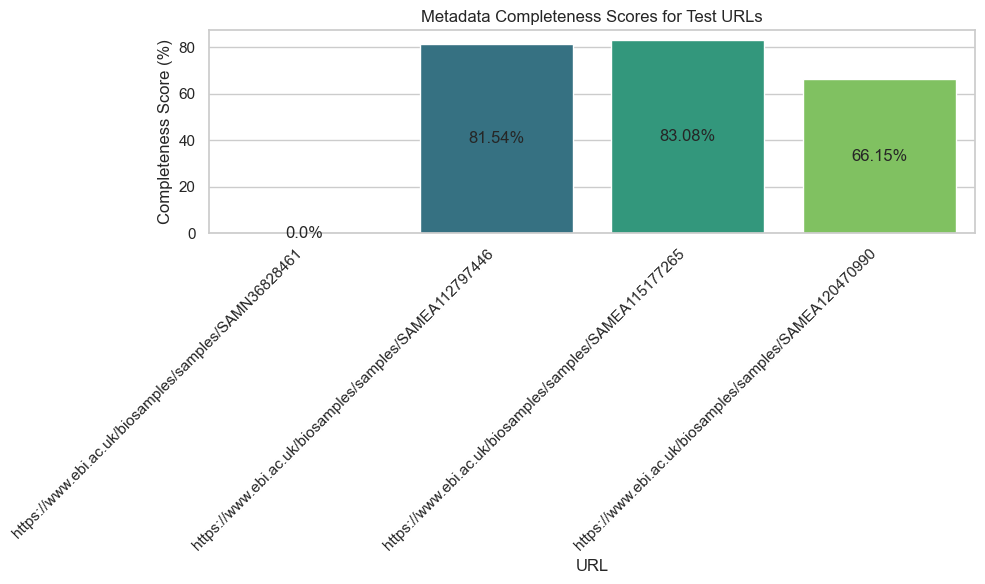

In [16]:
#!pip install seaborn

import seaborn as sns

# do the same with seaborn
plt.figure(figsize=(10, 6))

sns.set_theme(style="whitegrid")
sns.barplot(
    data=pd.DataFrame.from_dict(data, orient="index", columns=["completeness_score"]),
    x=data.keys(),
    hue=data.keys(),
    y="completeness_score",
    palette="viridis",
    legend=False,
)

# print the value of each bar in the center of the bar
for index, value in enumerate(data.values()):
    plt.text(index, value / 2, f"{value}%", ha="center", va="center")

plt.xlabel("URL")
plt.ylabel("Completeness Score (%)")
plt.title("Metadata Completeness Scores for Test URLs")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()